<a href="https://colab.research.google.com/github/pallabpodderrobin/crypto-volatility-engine/blob/main/crypto_volatility_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("btcusd_1-min_data.csv")
print(df.shape)
print(df.head())

(1732934, 6)
      Timestamp  Open  High   Low  Close  Volume
0  1.325412e+09  4.58  4.58  4.58   4.58     0.0
1  1.325412e+09  4.58  4.58  4.58   4.58     0.0
2  1.325412e+09  4.58  4.58  4.58   4.58     0.0
3  1.325412e+09  4.58  4.58  4.58   4.58     0.0
4  1.325412e+09  4.58  4.58  4.58   4.58     0.0


In [ ]:
df["Date"] = pd.to_datetime(df["Timestamp"], unit="s").dt.date
print(df["Date"].head())
print(f"Total rows: {len(df)}")

0    2012-01-01
1    2012-01-01
2    2012-01-01
3    2012-01-01
4    2012-01-01
Name: Date, dtype: object
Total rows: 1732934


In [ ]:
daily = df.groupby("Date")["Close"].last().reset_index()
daily = daily[daily["Close"] > 0].copy()
daily["Date"] = pd.to_datetime(daily["Date"])

print(f"Total days: {len(daily)}")
print(daily.head())

Total days: 1204
        Date  Close
0 2012-01-01   4.84
1 2012-01-02   5.00
2 2012-01-03   5.29
3 2012-01-04   5.57
4 2012-01-05   6.42


In [ ]:
close = daily["Close"].to_numpy()
dates = daily["Date"].to_numpy()

daily_return = np.diff(close) / close[:-1] * 100
dates = dates[1:]

print(f"Max return:  {daily_return.max():.2f}%")
print(f"Min return:  {daily_return.min():.2f}%")
print(f"Mean return: {daily_return.mean():.2f}%")

Max return:  35.81%
Min return:  -53.84%
Mean return: 0.48%


In [ ]:
volatile_mask = np.abs(daily_return) > 10
volatile_dates = dates[volatile_mask]
volatile_returns = daily_return[volatile_mask]

print(f"Volatile days (>10% swing): {volatile_mask.sum()}")
print("\nTop 5 most volatile days:")
top5 = np.argsort(np.abs(volatile_returns))[-5:][::-1]
for i in top5:
    print(f"{volatile_dates[i]} : {volatile_returns[i]:.2f}%")


Volatile days (>10% swing): 65

Top 5 most volatile days:
2013-04-11T00:00:00.000000000 : -53.84%
2013-04-10T00:00:00.000000000 : -43.36%
2013-04-12T00:00:00.000000000 : 35.81%
2013-04-17T00:00:00.000000000 : 33.48%
2012-08-19T00:00:00.000000000 : -28.28%


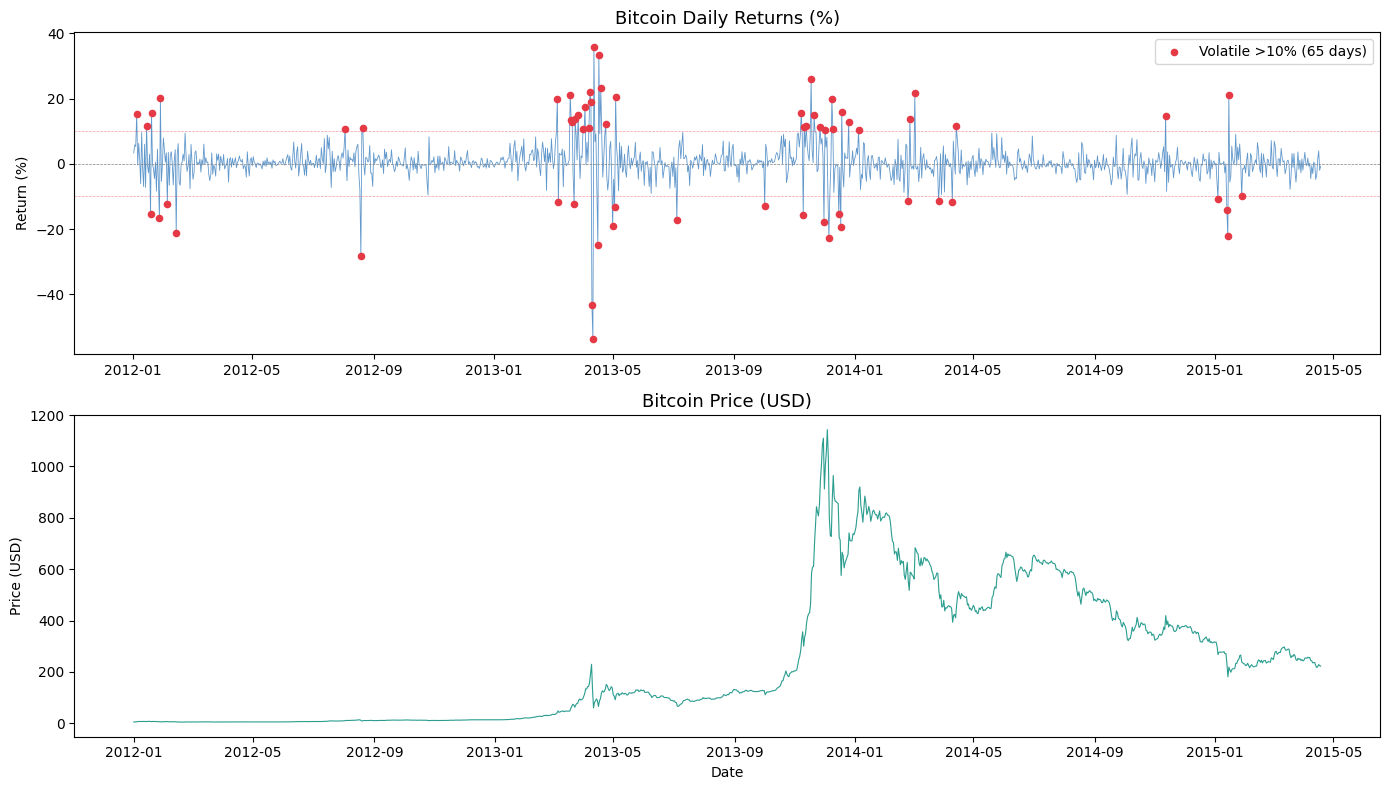

Done!


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Chart 1: Daily returns
axes[0].plot(dates, daily_return, color="#3a7ebf", linewidth=0.6, alpha=0.8)
axes[0].scatter(volatile_dates, volatile_returns,
                color="#e63946", s=20, zorder=5, label=f"Volatile >10% ({volatile_mask.sum()} days)")
axes[0].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[0].axhline(10, color="#e63946", linewidth=0.5, linestyle="--", alpha=0.5)
axes[0].axhline(-10, color="#e63946", linewidth=0.5, linestyle="--", alpha=0.5)
axes[0].set_title("Bitcoin Daily Returns (%)", fontsize=13)
axes[0].set_ylabel("Return (%)")
axes[0].legend()

# Chart 2: BTC price
axes[1].plot(daily["Date"], daily["Close"], color="#2a9d8f", linewidth=0.8)
axes[1].set_title("Bitcoin Price (USD)", fontsize=13)
axes[1].set_ylabel("Price (USD)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.savefig("btc_volatility.png", dpi=150)
plt.show()
print("Done!")